# Clasificación morfológica Madrid H3 — v4 (Random Forest, conjunto de métricas completo)

**Train set:** `labels_hex_manual (4).csv` (≈ 524 planificado / 200 espontáneo). Pozuelo / zona oeste excluida.

**42 variables, por bloques (§3.4 del TFM):**
- **A — Red viaria** (OSMnx): bearing_entropy, circuity, degree_std, dead_end_ratio, intersection_dens, internal_connect, edge_len_*, road_density_km, mean_degree.
- **B — Época** (catastro): cat_pct_* (5 bandas), cat_year_median, cat_year_iqr.
- **C — Forma construida**: cat_floors_mean/cv, cat_far, cat_footprint_ratio, cat_pct_residential, **cat_compactness_mean, cat_perimeter_density, cat_orientation_entropy**.
- **D-a — Armónicos de calle** (buffer 600 m): R4_all, BAS_all, ADI_*, _major, grid_crystallinity, block_area_cv, block_compact_mean, edge_len_cv.
- **D-b — Manzana desde huellas** (nuevas): edgeR4, rectangularity, area_local_cv, angle_align.

Las features se cachean en `clasificacion_morfologica/master_hex_v4.gpkg`.

In [12]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
plt.rcParams['figure.dpi'] = 120

BASE   = Path(r'C:\Users\Alvar\OneDrive\Desktop\estudios\economía\Artículos\MQUEA')
CLAS   = BASE / 'clasificacion_morfologica'
MASTER = CLAS / 'master_hex_v4.gpkg'        # caché de features (geometría + 42 métricas)
LABELS = BASE / 'labels_hex_manual (5).csv'
GPKG_OUT = BASE / 'madrid_clasificacion_final_v4.gpkg'
CRS = 'EPSG:25830'
POZUELO = ['Aravaca', 'El Plantío', 'Valdemarín']

# grupos de variables
NET  = ['bearing_entropy','mean_circuity','p90_circuity','degree_std','edge_len_std','dead_end_ratio',
        'intersection_dens','internal_connect','edge_len_mean','road_density_km','mean_degree']
ERA  = ['cat_pct_pre1860','cat_pct_1860_1940','cat_pct_1940_1960','cat_pct_1960_1985','cat_pct_post1985',
        'cat_year_median','cat_year_iqr']
CVOL = ['cat_floors_mean','cat_floors_cv','cat_far','cat_footprint_ratio','cat_pct_residential']
CFOOT= ['cat_compactness_mean','cat_perimeter_density','cat_orientation_entropy']
DA   = ['R4_all','BAS_all','ADI_mean_all','ADI_median_all','R4_major','BAS_major',
        'block_area_cv','block_compact_mean','grid_crystallinity_all','edge_len_cv_all','n_blocks','grid_crystallinity_major']
DB   = ['edgeR4','rectangularity','area_local_cv','angle_align']
FEATURE_SET = NET + ERA + CVOL + CFOOT + DA + DB

CLASS_WEIGHT = None        # no re-balancear (el planificado domina por extensión)
P_LOW, P_HIGH = 0.40, 0.60 # banda de transición
MIN_BLD_MAP = 5            # hexágonos con < 5 edificios -> gris en mapas
print('Config OK ·', len(FEATURE_SET), 'variables')

Config OK · 42 variables


## 1. Tabla de hexágonos (cargar caché o reensamblar)

In [13]:
def edge_r4(poly):
    xy = np.asarray(poly.exterior.coords); s = np.diff(xy, axis=0); L = np.hypot(s[:,0], s[:,1])
    if L.sum() == 0: return np.nan
    th = np.arctan2(s[:,1], s[:,0]); w = L/L.sum(); return float(abs(np.sum(w*np.exp(1j*4*th))))
def rectangularity(poly):
    mrr = poly.minimum_rotated_rectangle; return poly.area/mrr.area if mrr.area > 0 else np.nan
def edge_z(poly):
    xy = np.asarray(poly.exterior.coords); s = np.diff(xy, axis=0); L = np.hypot(s[:,0], s[:,1])
    if L.sum() == 0: return 0j
    th = np.arctan2(s[:,1], s[:,0]); w = L/L.sum(); return np.sum(w*np.exp(1j*4*th))
def bearing(poly):
    try:
        xs, ys = poly.minimum_rotated_rectangle.exterior.coords.xy
        e = [(xs[i+1]-xs[i], ys[i+1]-ys[i]) for i in range(4)]
        dx, dy = max(e, key=lambda v: v[0]**2+v[1]**2); return np.degrees(np.arctan2(dy, dx)) % 180
    except Exception: return np.nan

if MASTER.exists() and set(FEATURE_SET).issubset(set(gpd.read_file(MASTER, rows=1).columns)):
    g = gpd.read_file(MASTER).to_crs(CRS)
    print(f'Cargado de caché: {len(g)} hexágonos')
else:
    from scipy.stats import entropy as shannon
    from scipy.spatial import cKDTree
    print('Reensamblando (catastro + bloques)…')
    g = gpd.read_file(BASE/'madrid_morfologia_h3_v10.gpkg').to_crs(CRS)
    g = g[~g['barrio_nombre'].isin(POZUELO)].reset_index(drop=True)
    g['cell_km2'] = g.geometry.area/1e6
    g = g.drop(columns=[c for c in ['barrio_label','tipologia_train','pred_rf','tipologia_label','proba_max',
        'proba_espontaneo','proba_planificado','morfologia_continua','confianza_rf','label_excluida'] if c in g.columns])
    g = g.merge(gpd.read_file(BASE/'madrid_morfologia_h3_metricas_geometricas_v2.gpkg')[['hex_id']+
        ['R4_all','BAS_all','edge_len_cv_all','R4_major','BAS_major','ADI_mean_all','ADI_median_all',
         'block_area_cv','block_compact_mean','n_blocks','grid_crystallinity_all','grid_crystallinity_major']], on='hex_id', how='left')
    # C-huella desde catastro
    import pyogrio
    cat = pyogrio.read_dataframe(str(BASE/'Catastro'/'catastro_comunidad_de_madrid.shp'), columns=['gml_id']).to_crs(CRS)
    cat = cat[cat.geometry.notna() & cat.geometry.is_valid].reset_index(drop=True)
    cat['area'] = cat.geometry.area; cat['perim'] = cat.geometry.length
    cat = cat[(cat['area']>5) & (cat['perim']>0)].reset_index(drop=True)
    pts = gpd.GeoDataFrame({'area':cat['area'],'perim':cat['perim'],'bidx':cat.index}, geometry=cat.geometry.centroid, crs=CRS)
    j = gpd.sjoin(pts, g[['hex_id','geometry']], predicate='within', how='inner')
    j['compact'] = 4*np.pi*j['area']/(j['perim']**2)
    j['bear'] = [bearing(cat.geometry.values[i]) for i in j['bidx'].values]
    def oent(b):
        b=b.dropna()
        if len(b)<10: return np.nan
        h,_=np.histogram(b,bins=np.linspace(0,180,19)); p=h[h>0]/h.sum(); return shannon(p)/np.log(min(len(b),18))
    gb=j.groupby('hex_id'); hf=pd.DataFrame({'n_f':gb.size(),'cat_compactness_mean':gb['compact'].mean(),
        'sum_p':gb['perim'].sum(),'cat_orientation_entropy':gb['bear'].apply(oent)}).reset_index().merge(g[['hex_id','cell_km2']],on='hex_id',how='left')
    hf['cat_perimeter_density']=hf['sum_p']/hf['cell_km2']; hf.loc[hf['n_f']<10,['cat_compactness_mean','cat_perimeter_density']]=np.nan
    g=g.merge(hf[['hex_id','cat_compactness_mean','cat_perimeter_density','cat_orientation_entropy']],on='hex_id',how='left')
    # D-b: agregar manzanas a hexágono
    blk=gpd.read_file(CLAS/'bloques_huellas.gpkg'); bc=gpd.GeoDataFrame(blk[DB].copy(),geometry=blk.geometry.centroid,crs=CRS)
    jb=gpd.sjoin(bc,g[['hex_id','geometry']],predicate='within',how='inner'); ag=jb.groupby('hex_id')[DB].mean(); ag['n_blk']=jb.groupby('hex_id').size()
    ag.loc[ag['n_blk']<2,DB]=np.nan; g=g.merge(ag[DB],on='hex_id',how='left')
    g.to_file(MASTER); print(f'  reensamblado y cacheado: {len(g)} hexágonos')

FEATS = [f for f in FEATURE_SET if f in g.columns]
print('features disponibles:', len(FEATS), '/', len(FEATURE_SET))

Cargado de caché: 2887 hexágonos
features disponibles: 42 / 42


## 2. Etiquetas de entrenamiento

In [14]:
lab = pd.read_csv(LABELS); lab['hex_id'] = lab['hex_id'].astype(str)
g['label'] = g['hex_id'].astype(str).map(dict(zip(lab['hex_id'], pd.to_numeric(lab['tipologia_train'], errors='coerce'))))
n1 = int((g.label==1).sum()); n0 = int((g.label==0).sum())
print(f'Entrenamiento: {n1} planificado / {n0} espontáneo  ({n1/(n1+n0)*100:.0f}/{n0/(n1+n0)*100:.0f})')
print(f'Sin etiqueta (predicción): {int(g.label.isna().sum())}')

Entrenamiento: 524 planificado / 209 espontáneo  (71/29)
Sin etiqueta (predicción): 2154


## 3. Cohen's d — poder discriminante (d>0 espontáneo · d<0 planificado)

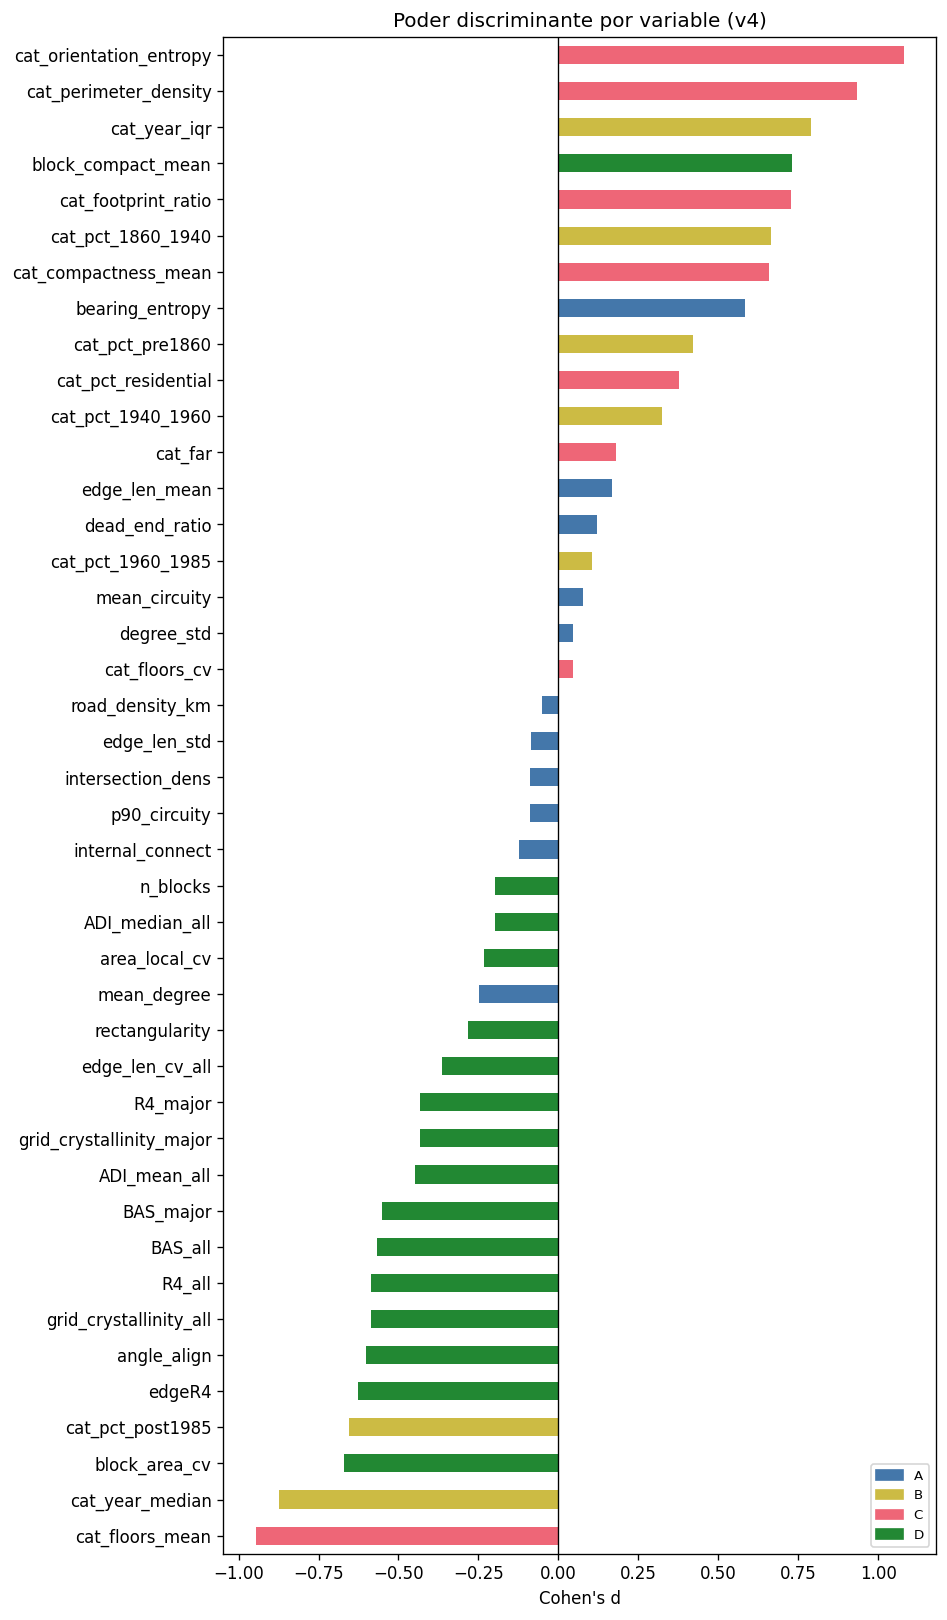

cat_orientation_entropy    1.08
cat_floors_mean           -0.95
cat_perimeter_density      0.93
cat_year_median           -0.87
cat_year_iqr               0.79
block_compact_mean         0.73
cat_footprint_ratio        0.73
block_area_cv             -0.67
cat_pct_1860_1940          0.66
cat_compactness_mean       0.66
cat_pct_post1985          -0.66
edgeR4                    -0.63


In [15]:
esp, plan = g.label==0, g.label==1
grp = {**{v:'A' for v in NET},**{v:'B' for v in ERA},**{v:'C' for v in CVOL+CFOOT},**{v:'D' for v in DA+DB}}
col = {'A':'#4477aa','B':'#ccbb44','C':'#ee6677','D':'#228833'}
d = {}
for v in FEATS:
    c = pd.to_numeric(g[v], errors='coerce'); s = c[esp|plan].std()
    d[v] = (c[esp].mean()-c[plan].mean())/s if s and s>0 else np.nan
ds = pd.Series(d).sort_values()
fig, ax = plt.subplots(figsize=(8, 0.3*len(ds)+1))
ds.plot(kind='barh', ax=ax, color=[col[grp[i]] for i in ds.index])
ax.axvline(0, color='k', lw=0.8); ax.set_xlabel("Cohen's d"); ax.set_title("Poder discriminante por variable (v4)")
ax.legend(handles=[mpatches.Patch(color=c,label=k) for k,c in col.items()], fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()
print(ds.reindex(ds.abs().sort_values(ascending=False).index).head(12).round(2).to_string())

## 4. Aportación por bloque de variables (RF, validación cruzada)

In [16]:
def cv_f1(feats):
    fs=[f for f in feats if f in g.columns]; m=g.label.isin([0,1])
    X=SimpleImputer(strategy='median').fit_transform(g.loc[m,fs]); y=g.loc[m,'label'].astype(int).values
    rf=RandomForestClassifier(n_estimators=400,max_features='sqrt',min_samples_leaf=3,class_weight=CLASS_WEIGHT,random_state=42,n_jobs=-1)
    s=cross_val_score(rf,X,y,cv=StratifiedKFold(5,shuffle=True,random_state=42),scoring='f1_macro'); return s.mean(),s.std(),len(fs)
print(f'{"conjunto":18s} {"n":>4s}  CV F1-macro')
for nm,fs in [('A',NET),('A+B',NET+ERA),('A+B+C',NET+ERA+CVOL+CFOOT),('A+B+C+Da',NET+ERA+CVOL+CFOOT+DA),('TODO',FEATURE_SET)]:
    mn,sd,k=cv_f1(fs); print(f'{nm:18s} {k:4d}  {mn:.3f} ± {sd:.3f}')

conjunto              n  CV F1-macro
A                    11  0.560 ± 0.044
A+B                  18  0.775 ± 0.038
A+B+C                26  0.848 ± 0.012
A+B+C+Da             38  0.841 ± 0.015
TODO                 42  0.847 ± 0.021


## 5. Modelo final + predicción

In [17]:
mask = g.label.isin([0,1]); imp = SimpleImputer(strategy='median')
Xtr = imp.fit_transform(g.loc[mask, FEATS]); ytr = g.loc[mask,'label'].astype(int).values
rf = RandomForestClassifier(n_estimators=400, max_features='sqrt', min_samples_leaf=3,
                            class_weight=CLASS_WEIGHT, random_state=42, n_jobs=-1)
cv = cross_val_score(rf, Xtr, ytr, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1_macro')
rf.fit(Xtr, ytr)
g['p_esp'] = rf.predict_proba(imp.transform(g[FEATS]))[:,0]
g['pred_rf'] = np.where(g['p_esp']>=0.5, 0, 1)
g['tipologia_label'] = np.select([g['p_esp']>=P_HIGH, g['p_esp']<=P_LOW], ['Espontáneo','Planificado'], default='Transición')
g['morfologia_continua'] = 1 - g['p_esp']
print(f'CV F1-macro: {cv.mean():.3f} ± {cv.std():.3f}   ({len(FEATS)} variables)')
print('\nTipología ciudad (banda {}-{}):'.format(P_LOW, P_HIGH)); print(g['tipologia_label'].value_counts())

CV F1-macro: 0.847 ± 0.021   (42 variables)

Tipología ciudad (banda 0.4-0.6):
tipologia_label
Planificado    2517
Espontáneo      237
Transición      133
Name: count, dtype: int64


## 6. Importancia de variables

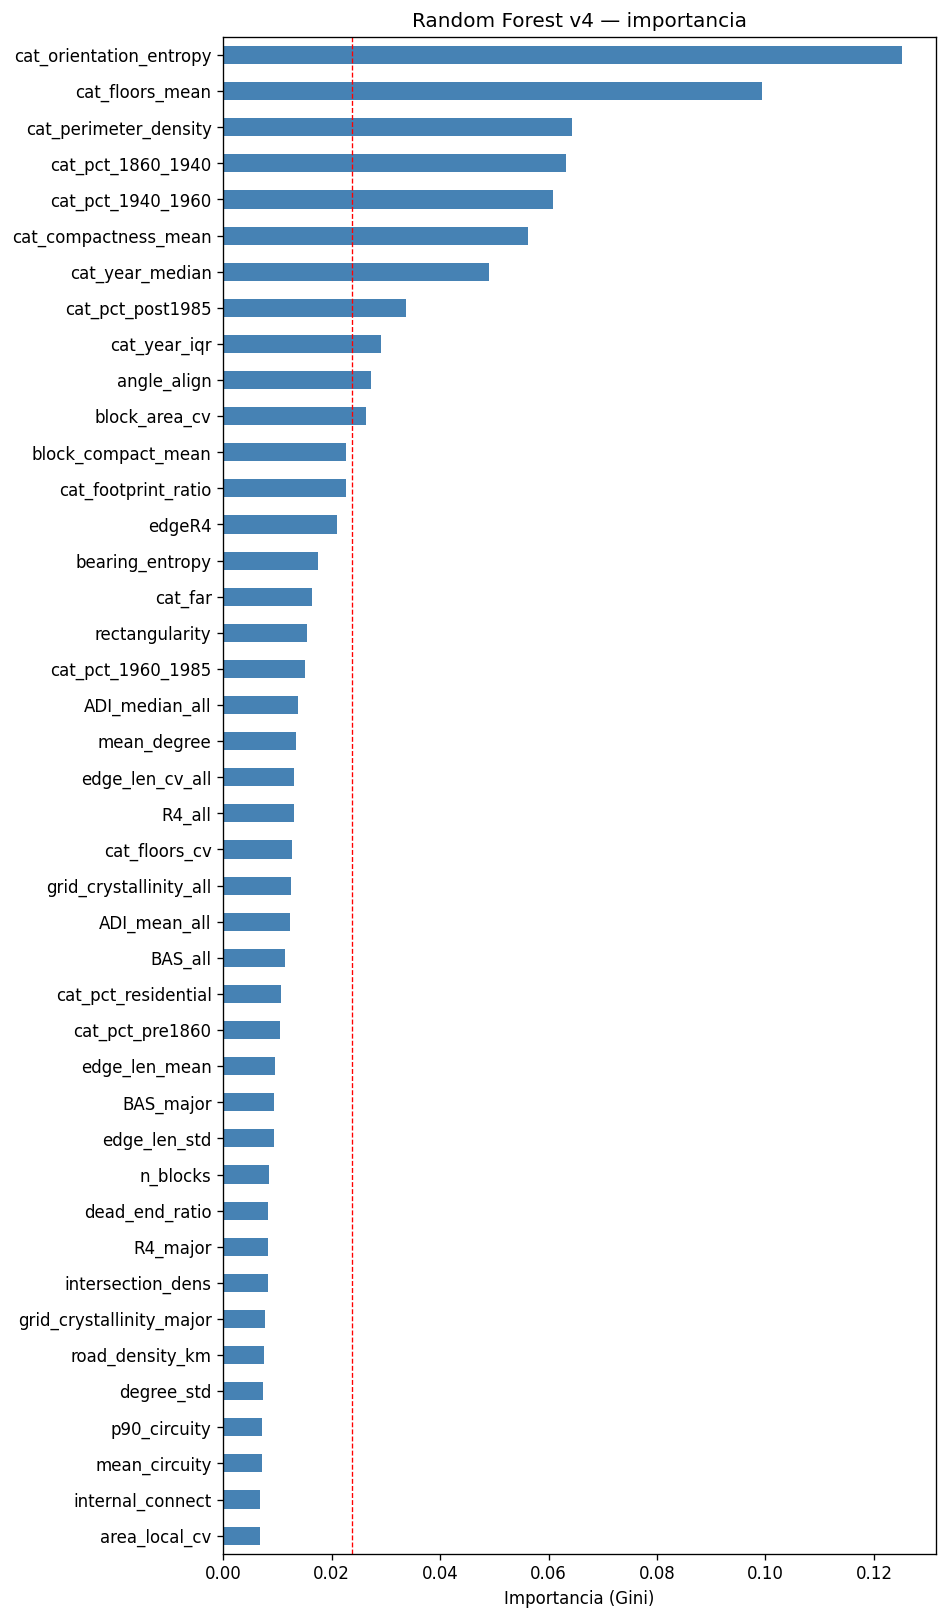

cat_orientation_entropy    0.125
cat_floors_mean            0.099
cat_perimeter_density      0.064
cat_pct_1860_1940          0.063
cat_pct_1940_1960          0.061
cat_compactness_mean       0.056
cat_year_median            0.049
cat_pct_post1985           0.034
cat_year_iqr               0.029
angle_align                0.027
block_area_cv              0.026
block_compact_mean         0.023


In [18]:
impv = pd.Series(rf.feature_importances_, index=FEATS).sort_values()
fig, ax = plt.subplots(figsize=(8, 0.3*len(impv)+1))
impv.plot(kind='barh', ax=ax, color='steelblue'); ax.axvline(1/len(FEATS), color='red', ls='--', lw=0.8)
ax.set_xlabel('Importancia (Gini)'); ax.set_title('Random Forest v4 — importancia'); plt.tight_layout(); plt.show()
print(impv.sort_values(ascending=False).head(12).round(3).to_string())

## 7. Validación por barrio

In [19]:
val = (g[g['barrio_nombre'].notna()].groupby('barrio_nombre')
       .agg(n=('p_esp','size'), P_esp=('p_esp','mean')).query('n>=8').sort_values('P_esp', ascending=False))
pd.set_option('display.max_rows', 200)
print('=== TOP 10 más espontáneos ==='); print(val.head(10).round(2).to_string())
print('\n=== TOP 10 más planificados ==='); print(val.tail(10).round(2).to_string())
try:
    import osmnx as ox
    poly = ox.geocode_to_gdf('El Cañaveral, Madrid, Spain').to_crs(CRS).geometry.iloc[0]
    mc = g.geometry.centroid.within(poly)
    if mc.sum(): print(f'\nEl Cañaveral (PAU): P_esp medio={g.loc[mc.values,"p_esp"].mean():.2f}  (esperado: planificado)')
except Exception as e:
    print('\n(Cañaveral no geocodificado)')

=== TOP 10 más espontáneos ===
                   n  P_esp
barrio_nombre              
Berruguete         8   0.86
Embajadores        9   0.86
Universidad        9   0.81
Opañel            10   0.79
Valdeacederas     12   0.67
Puerta del Ángel  14   0.64
Palacio           13   0.64
Comillas           8   0.59
San Isidro        17   0.56
El Viso           16   0.55

=== TOP 10 más planificados ===
                       n  P_esp
barrio_nombre                  
Ríos Rosas            10   0.08
San Pascual            9   0.07
Los Ángeles           19   0.07
Orcasitas             12   0.06
La Paz                20   0.06
Marroquina            17   0.06
Arcos                 12   0.04
Pavones                9   0.03
Valdebernardo         20   0.03
Ensanche de Vallecas  54   0.03

El Cañaveral (PAU): P_esp medio=0.08  (esperado: planificado)


## 8. Barrido de umbral

        n_esp  %esp
umbral             
0.40      370  13.0
0.45      327  11.0
0.50      287  10.0
0.55      259   9.0
0.60      237   8.0
0.65      206   7.0
0.70      178   6.0


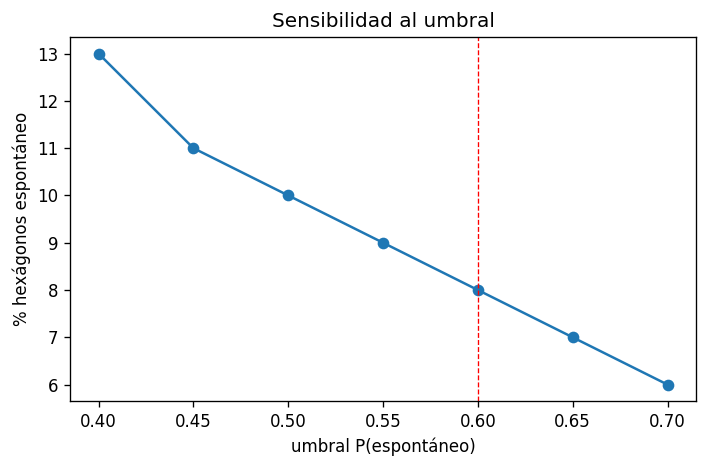

In [20]:
rows=[(t, int((g['p_esp']>=t).sum())) for t in [0.40,0.45,0.50,0.55,0.60,0.65,0.70]]
tab=pd.DataFrame(rows,columns=['umbral','n_esp']).set_index('umbral'); tab['%esp']=(tab['n_esp']/len(g)*100).round(0)
print(tab.to_string())
fig,ax=plt.subplots(figsize=(6,4)); ax.plot(tab.index,tab['%esp'],'o-'); ax.axvline(P_HIGH,color='red',ls='--',lw=0.8)
ax.set_xlabel('umbral P(espontáneo)'); ax.set_ylabel('% hexágonos espontáneo'); ax.set_title('Sensibilidad al umbral'); plt.tight_layout(); plt.show()

## 9. Mapas (ciudad completa)

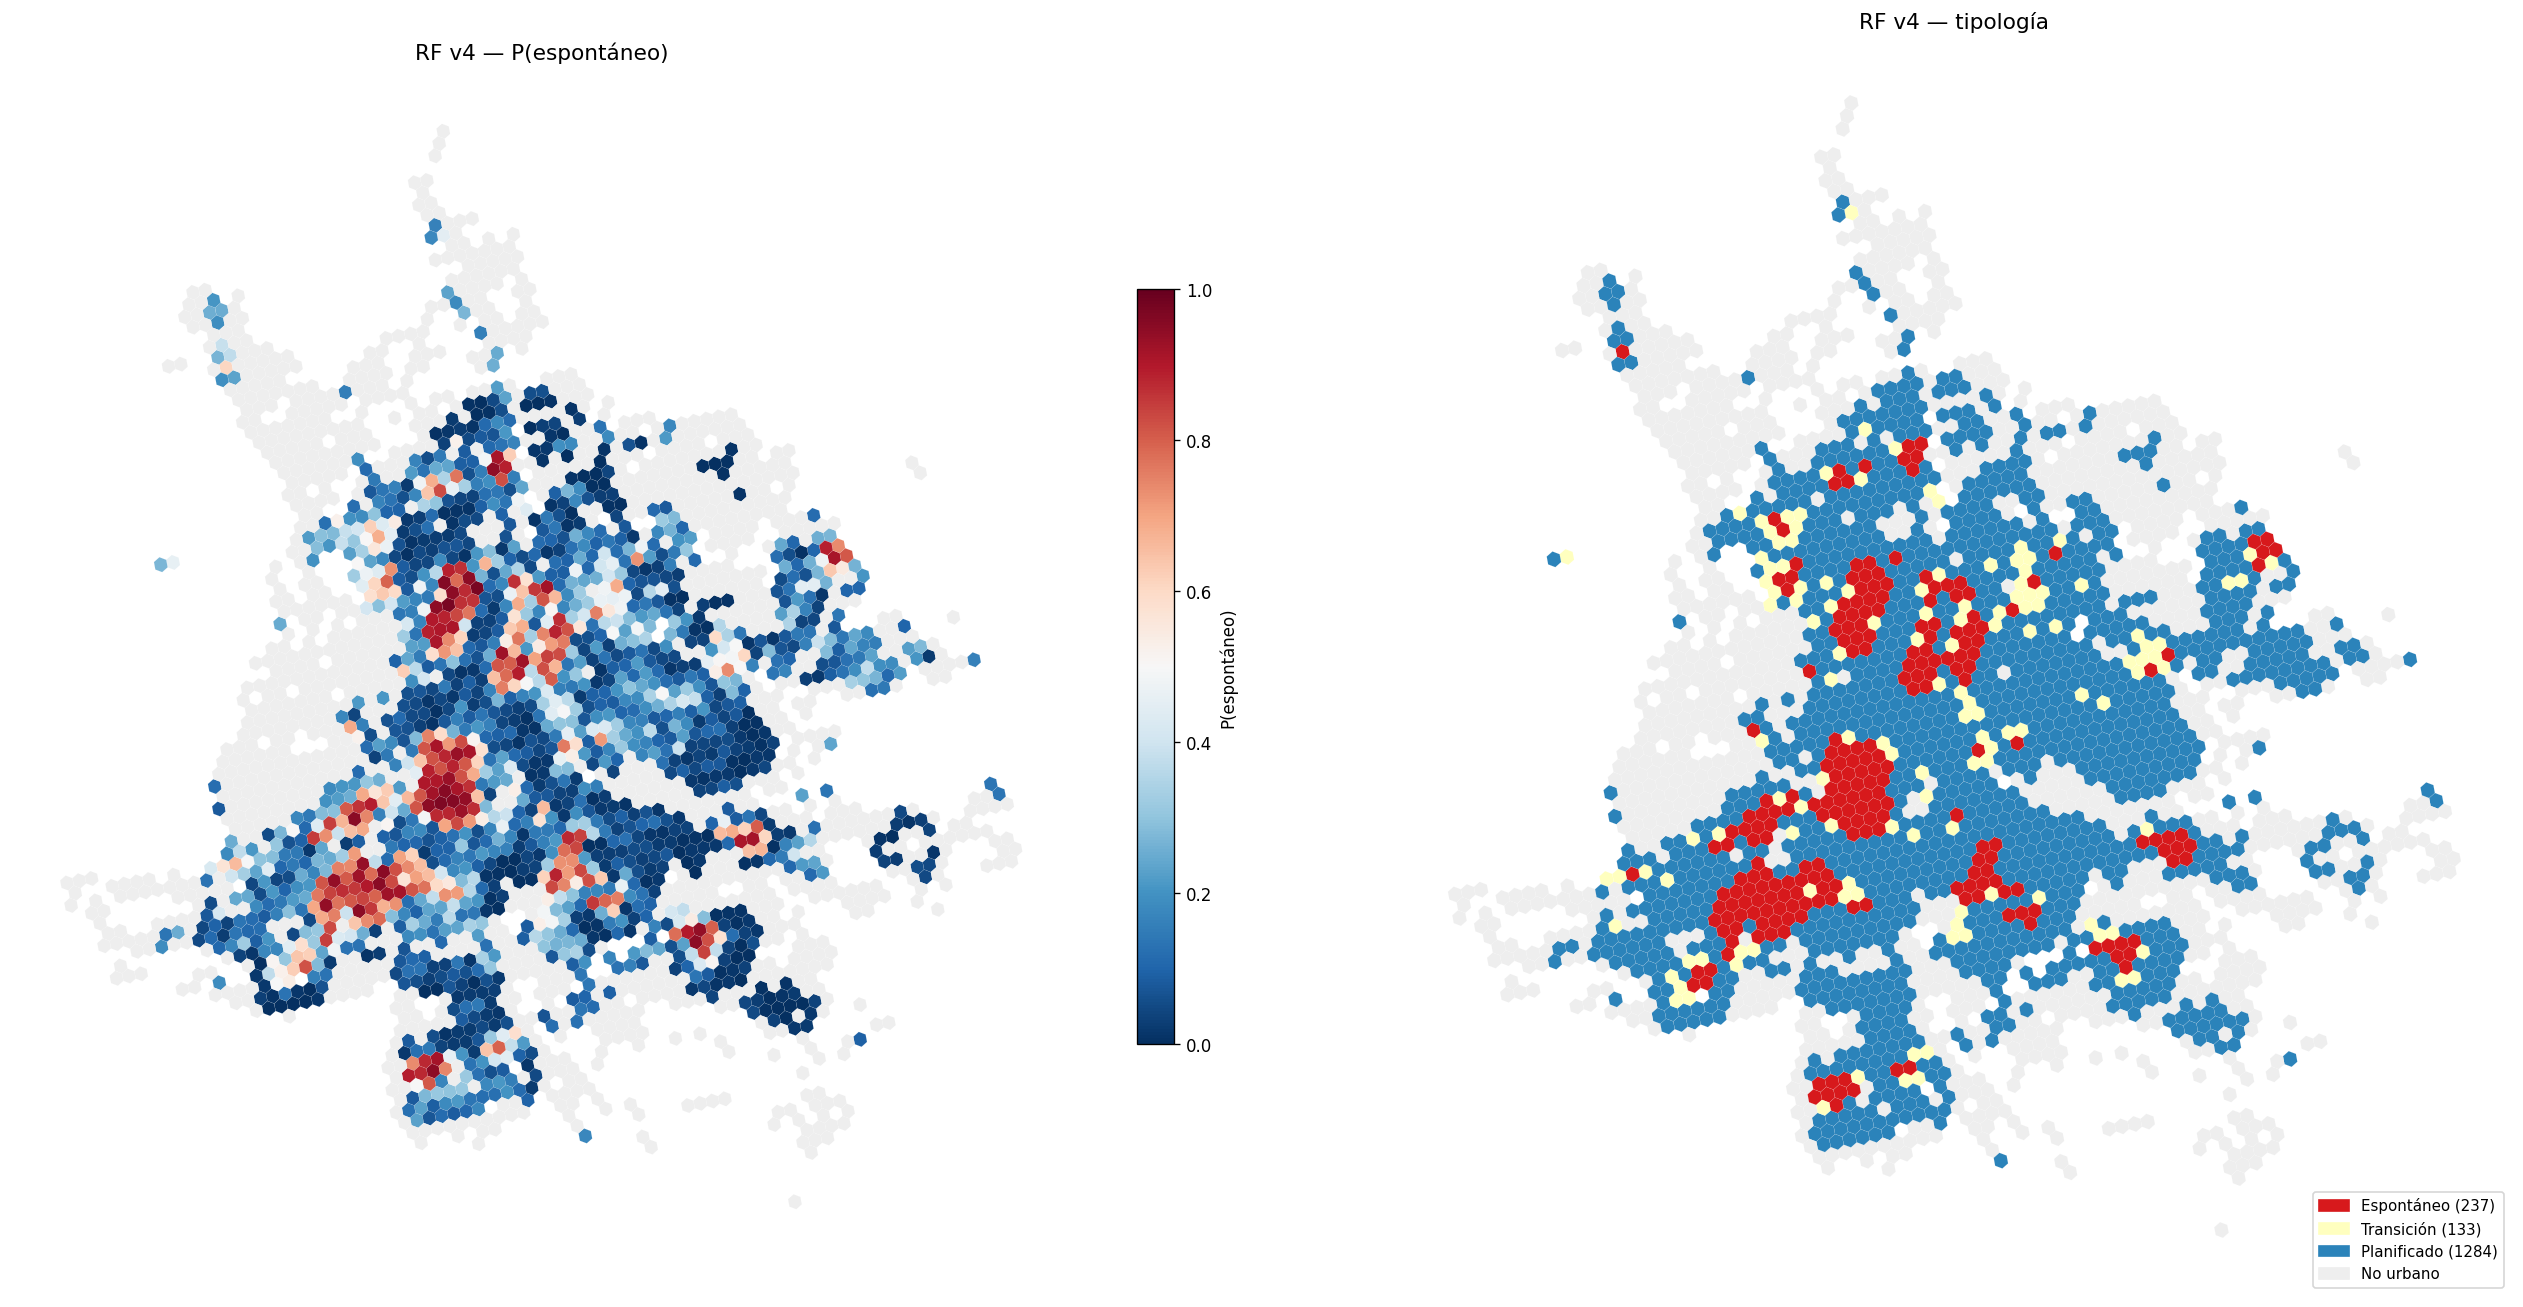

In [21]:
urb = pd.to_numeric(g['cat_n_buildings'], errors='coerce').fillna(0) >= MIN_BLD_MAP
gp = g.copy(); gp.loc[~urb,'p_esp'] = np.nan
def disc(p): return '#d7191c' if p>=P_HIGH else ('#2b83ba' if p<=P_LOW else '#ffffbf')
g['_c'] = g['p_esp'].map(disc); g.loc[~urb,'_c'] = '#eeeeee'
fig, ax = plt.subplots(1, 2, figsize=(22, 11))
gp.plot(column='p_esp', cmap='RdBu_r', vmin=0, vmax=1, legend=True,
        legend_kwds={'label':'P(espontáneo)','shrink':0.6}, ax=ax[0], linewidth=0.05, edgecolor='white',
        missing_kwds={'color':'#eeeeee'})
ax[0].set_title('RF v4 — P(espontáneo)', fontsize=13); ax[0].set_axis_off()
g.plot(color=g['_c'], ax=ax[1], linewidth=0.05, edgecolor='white')
vc=g.loc[urb,'tipologia_label'].value_counts()
ax[1].legend(handles=[mpatches.Patch(color='#d7191c',label=f"Espontáneo ({vc.get('Espontáneo',0)})"),
                      mpatches.Patch(color='#ffffbf',label=f"Transición ({vc.get('Transición',0)})"),
                      mpatches.Patch(color='#2b83ba',label=f"Planificado ({vc.get('Planificado',0)})"),
                      mpatches.Patch(color='#eeeeee',label='No urbano')], loc='lower right', fontsize=9)
ax[1].set_title('RF v4 — tipología', fontsize=13); ax[1].set_axis_off()
plt.tight_layout(); plt.show()

## 10. Guardado

In [22]:
cols = [c for c in g.columns if c not in ['_c','centroid']]
g[cols].to_file(GPKG_OUT, driver='GPKG')
print('Guardado:', GPKG_OUT.name, '·', len(g), 'hex')

Guardado: madrid_clasificacion_final_v4.gpkg · 2887 hex
